# APIPhoenix — Dataset Exploration
**AI-Powered API Documentation & Testing Portal · SDAI Himshikhar 2026 · Team Phoenix**

This notebook explores the starter dataset (`data/endpoints.json`) and demonstrates the core
generation engines that power the portal. The dataset was authored for this project following
the brief's schema: `method, path, request_body, response_body, auth_required, error_codes`.

In [1]:
import json, collections
import matplotlib.pyplot as plt

with open('../data/endpoints.json') as f:
    ds = json.load(f)
eps = ds['endpoints']
print(f"Records: {ds['count']}  ·  Schema v{ds['schema_version']}")
print(f"Services: {sorted(set(e['service'] for e in eps))}")

Records: 49  ·  Schema v1.0
Services: ['EduSphere', 'MediTrack', 'PayBridge', 'RideLink', 'ShopStack']


## 1 · A sample record
Every record follows the required schema, enriched with `service`, `summary`, and `tags`.

In [2]:
print(json.dumps(eps[11], indent=2))

{
  "id": "ep_012",
  "service": "ShopStack",
  "method": "POST",
  "path": "/api/v1/orders",
  "summary": "Place an order from the current cart",
  "auth_required": true,
  "request_body": {
    "cart_id": "crt_55",
    "address_id": "adr_12",
    "payment_method": "upi"
  },
  "response_body": {
    "order_id": "ord_3001",
    "status": "confirmed",
    "eta_days": 3,
    "total_inr": 1798.0
  },
  "error_codes": [
    {
      "code": 401,
      "message": "Unauthorized \u2014 missing or invalid bearer token"
    },
    {
      "code": 422,
      "message": "Validation failed \u2014 see field errors in response"
    },
    {
      "code": 402,
      "message": "Payment authorization failed"
    },
    {
      "code": 500,
      "message": "Internal server error"
    }
  ],
  "tags": [
    "orders",
    "payments"
  ]
}


## 2 · Distribution by service and HTTP method

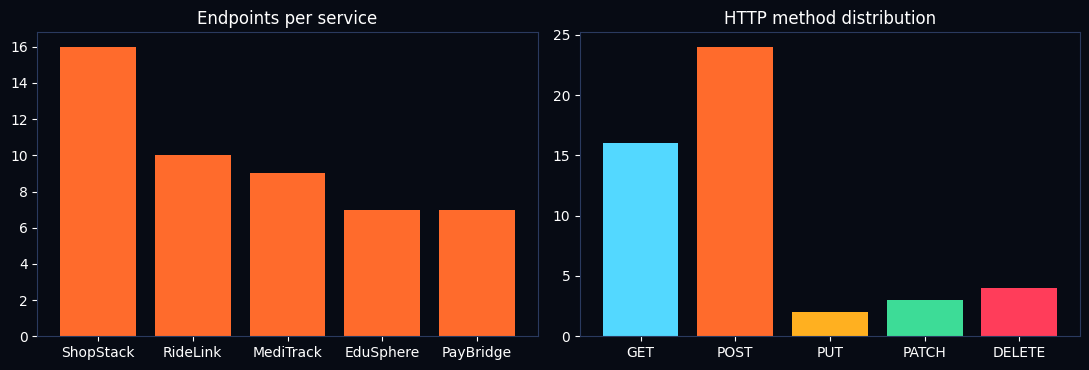

In [3]:
svc = collections.Counter(e['service'] for e in eps)
mth = collections.Counter(e['method'] for e in eps)

INK, EMBER, CYAN = '#070B14', '#FF6B2C', '#53D8FF'
MCOL = {'GET':'#53D8FF','POST':'#FF6B2C','PUT':'#FFB020','PATCH':'#3DDC97','DELETE':'#FF3D5A'}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
fig.patch.set_facecolor(INK)
for ax in (a1, a2):
    ax.set_facecolor(INK)
    ax.tick_params(colors='white')
    for s in ax.spines.values(): s.set_color('#2A3A5F')

a1.bar(svc.keys(), svc.values(), color=EMBER)
a1.set_title('Endpoints per service', color='white')
order = ['GET','POST','PUT','PATCH','DELETE']
a2.bar(order, [mth[m] for m in order], color=[MCOL[m] for m in order])
a2.set_title('HTTP method distribution', color='white')
plt.tight_layout(); plt.show()

## 3 · Contract health checks
Realism checks: auth coverage, declared error codes, and parameter styles.

In [4]:
auth = sum(e['auth_required'] for e in eps)
path_param = sum('{' in e['path'] for e in eps)
query = sum(1 for e in eps if e.get('request_body') and 'query' in e['request_body'])
body = sum(1 for e in eps if e.get('request_body') and 'query' not in (e['request_body'] or {}))
errf = collections.Counter(c['code'] for e in eps for c in e['error_codes'])

print(f"Auth-required endpoints : {auth}/{len(eps)} ({auth/len(eps):.0%})")
print(f"Path-parameter routes   : {path_param}")
print(f"Query-param requests    : {query}   ·   JSON-body requests: {body}")
print("\nDeclared error codes (frequency):")
for code, n in errf.most_common():
    print(f"  {code}  {'█'*n}  {n}")

Auth-required endpoints : 40/49 (82%)
Path-parameter routes   : 24
Query-param requests    : 7   ·   JSON-body requests: 29

Declared error codes (frequency):
  401  ██████████████████████████████████████████  42
  404  ██████████████████████████████  30
  422  ███████████████████████████  27
  409  ███████████████  15
  500  ████████████  12
  403  ████████████  12
  429  ██████  6
  402  ███  3
  503  █  1
  423  █  1


## 4 · The Phoenix engine — deterministic generation demo
The portal's AI layer calls Claude; when the API is unreachable, this local rule engine
produces the same three artifacts from the contract alone. Here we run it directly.

In [5]:
import sys; sys.path.insert(0, '..')
from src.main import generate_docs, generate_tests, run_suite, explain_error

ep = next(e for e in eps if e['path'] == '/api/v1/orders' and e['method'] == 'POST')
docs = generate_docs(ep)
print(f"engine = {docs['engine']}\n")
print(docs['markdown'][:600])

engine = phoenix

### Overview
Place an order from the current cart. `POST` endpoint of the **ShopStack** service — requires a bearer token.

### Request fields
- `cart_id` (string)
- `address_id` (string)
- `payment_method` (string)

### Success response
Returns fields: `order_id`, `status`, `eta_days`, `total_inr`

### Error handling
- `401` — Unauthorized — missing or invalid bearer token
- `422` — Validation failed — see field errors in response
- `402` — Payment authorization failed
- `500` — Internal server error


In [6]:
suite = generate_tests(ep)
results = run_suite(ep, suite['cases'])
passed = sum(r['result'] == 'pass' for r in results)
print(f"Suite ({suite['engine']}) — {passed}/{len(results)} passed\n")
for r in results:
    print(f"  {r['result'].upper():4} · {r['name']}  (expect {r['expect']})")

Suite (phoenix) — 4/4 passed

  PASS · Happy path returns success  (expect 2xx)
  PASS · Rejects missing bearer token  (expect 401)
  PASS · Rejects malformed body  (expect 422)
  PASS · Wrong method returns 405  (expect 405)


In [7]:
diag = explain_error('{"error":{"code":429,"message":"Rate limit exceeded"}}', ep)
print(diag['markdown'])

### Diagnosis
HTTP 429 — **Rate limited**. Too many requests. Back off and respect Retry-After.

### What to do next
1. Reproduce with the Playground sample request.
2. Compare input against the documented schema.
3. Attach the request ID to a bug report if it persists.


## 5 · Takeaways
- All **49 endpoints** load, validate, and generate complete docs + suites through the fallback engine alone — the portal's availability floor.
- The dataset deliberately mixes public/authenticated routes, path/query/body parameters, and **domain business errors** (402 payment, 409 conflicts, 423 locked, 429 rate limits), so the AI layer is tested on realistic variety.
- The test runner is **contract-grounded**: expected statuses are validated against what each endpoint actually declares.